# Overview

This notebook will roughly follow the presentation slides (from ICONS 2025)

- We first look at STACS conceptually (slides)
- And then go through an example (this notebook)
- Defining and constructing an network
- Running and visualizing the simulation outputs
- Demonstrating the partitioning capabilities

In [2]:
# Import libraries
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import yaml

matplotlib.rcParams.update({'font.size': 16})

In [3]:
# Create a new directory for simulation
netwkdir = './reservoir'
recordir = 'record'
inputdir = 'input'
filebase = 'network'

os.makedirs(netwkdir, exist_ok=True)
os.makedirs(netwkdir + '/' + recordir, exist_ok=True)
os.makedirs(netwkdir + '/' + inputdir, exist_ok=True)

# Defining Neural Network

In [4]:
## Helper functions for configuration
# Work in progress, eventually a pystacs

# Model registry
model_registry = dict()
model_registry['izhi_neuron'] = 'izhi_neuron_clamp'
model_registry['izhi_syn_stdp'] = 'izhi_syn_stdp'
model_registry['izhi_syn'] = 'simple_synapse'
model_registry['input_syn'] = 'spike_clamp'
model_registry['spike_input'] = 'spike_input'

# Returns a substrate model dictionary
def substrate_model(type, model_name, model_type, params=None, states=None, ports=None):
    # Initialize model dictionary
    model_dict = dict()
    model_dict['type'] = type
    model_dict['modname'] = model_name
    model_dict['modtype'] = model_registry[model_type]
    
    # Parameters (shared by model instances)
    if params is not None:
        model_dict['param'] = list()
        for k,v in params.items():
            model_dict['param'].append({'name': k, 'value': v})

    # States (mutable or unique per model instance)
    if states is not None:
        model_dict['state'] = list()
        for k,v in states.items():
            if isinstance(v, dict):
                model_dict['state'].append({'name': k, **v})
            else:
                model_dict['state'].append({'name': k, 'init': 'constant', 'value': v})
            if k == 'delay':
                model_dict['state'][-1]['rep'] = 'tick'

    # Ports (for external communication)
    if ports is not None:
        model_dict['port'] = list()
        for k,v in ports.items():
            model_dict['port'].append({'name': k, 'value': v})

    # Return the model dictionary
    return model_dict

def vertex_model(model_name, model_type, params=None, states=None):
    return substrate_model('vertex', model_name, model_type, params, states)
    
def edge_model(model_name, model_type, params=None, states=None):
    return substrate_model('edge', model_name, model_type, params, states)
    
def stream_model(model_name, model_type, params=None, states=None, ports=None):
    return substrate_model('stream', model_name, model_type, params, states, ports)

# Returns a graph model dictionary
def graph_pop(model_name, order, shape=None):
    # Initialize model dictionary
    model_dict = dict()
    model_dict['type'] = 'vertex'
    model_dict['modname'] = model_name
    model_dict['order'] = order

    # Populations have a shape
    if shape is not None:
        model_dict.update(shape)
    model_dict['coord'] = [0.0, 0.0, 0.0]
    
    # Return the model dictionary
    return model_dict

def graph_stream(model_name):
    # Initialize model dictionary
    model_dict = dict()
    model_dict['type'] = 'stream'
    model_dict['modname'] = model_name
    model_dict['coord'] = [0.0, 0.0, 0.0]
    
    # Return the model dictionary
    return model_dict

def graph_conn(source, target, model_name, distance=None, connect=None, cutoff=None):
    # Initialize model dictionary
    model_dict = dict()
    model_dict['type'] = 'edge'
    model_dict['source'] = source
    model_dict['target'] = [target]
    model_dict['modname'] = model_name

    # Distance computation (default is euclidean)
    if distance is not None:
        for k,v in distance.items():
            model_dict['dist'] = k
            model_dict.update(v)
    
    # Connection parameterization
    if connect is not None:
        model_dict['connect'] = list()
        for k,v in connect.items():
            if isinstance(v, dict):
                model_dict['connect'].append({'type': k, **v})
    
    # Connection cutoff distances
    if cutoff is not None:
        model_dict['cutoff'] = cutoff
    else:
        model_dict['cutoff'] = 0.0
        
    # Return the model dictionary
    return model_dict

# Reorganize the list of model dictionaries
def generate_model_yaml(substrate_models):
    # Reorder models in stream, vertex, edge order
    sort_key = {'stream': 0, 'vertex': 1, 'edge': 2}
    substrate_list = sorted(substrate_models,
                            key = lambda x: sort_key[x['type']])
    
    # Return model dictionary list
    return substrate_list

# Collect the different graph models into a combined dictionary
def generate_graph_yaml(graph_models):
    graph_dict = dict()
    graph_dict['stream'] = list()
    graph_dict['vertex'] = list()
    graph_dict['edge'] = list()

    # Add to collection and remove 'type'
    for model in graph_models:
        if model['type'] == 'stream':
            graph_dict['stream'].append(model)
        if model['type'] == 'vertex':
            graph_dict['vertex'].append(model)
        if model['type'] == 'edge':
            graph_dict['edge'].append(model)
            
    # Return model dictionary
    return graph_dict

# Returns a simulation configuration
def generate_conf_yaml(sim_conf, part_conf, time_conf):
    conf_dict = dict()

    # General simulation information
    conf_dict.update(sim_conf)
    conf_dict.setdefault('runmode', 'buildsim')
    conf_dict.setdefault('plastic', True)
    conf_dict.setdefault('episodic', False)
    conf_dict.setdefault('loadbal', False)

    # Network partitions
    conf_dict.update(part_conf)
    conf_dict.setdefault('recordir', 'record')
    conf_dict.setdefault('groupdir', 'group')
    conf_dict.setdefault('fileload', '')
    conf_dict.setdefault('filesave', '.out')

    # Simulation timing
    conf_dict.update(time_conf)
    conf_dict.setdefault('teventq', 20.0)
    conf_dict.setdefault('tdisplay', 1000.0)
    conf_dict.setdefault('trecord', 10000.0)
    conf_dict.setdefault('tsave', 1000000.0)
    conf_dict.setdefault('tbalance', 1000000.0)

    # Return model dictionary
    return conf_dict

## Neuron and Synapse Models

In [5]:
# Neuron and synapse dynamics are written in C++
# but are parameterized through a YAML configuration file

# Parameterization for regular-spiking (excitatory) izhikevich neuron
neuron_rs_param = {'a': 0.02, 'b': 0.2, 'c': -65.0, 'd': 8.0}
# Parameterization for fast-spiking (inhibitory) izhikevich neuron
neuron_fs_param = {'a': 0.1, 'b': 0.2, 'c': -65.0, 'd': 2.0}
# Parameterization for background thalamic input
thal_bg_param = {'thal_rate': 1.0, 'thal_ampl': 20.0}

# Initial state for the spiking neurons
neuron_state = {'v': -65.0, 'u': -13.0}

# Create the neuron models
izhi_ex = vertex_model('izhi_ex',
                       'izhi_neuron',
                       params = {**neuron_rs_param, **thal_bg_param},
                       states = neuron_state)

izhi_in = vertex_model('izhi_in',
                       'izhi_neuron',
                       params = {**neuron_fs_param, **thal_bg_param},
                       states = neuron_state)

izhi_input = vertex_model('izhi_input',
                          'izhi_neuron',
                          params = neuron_rs_param,
                          states = neuron_state)

# Parameterization for excitatory connections with STDP
syn_stdp_param = {'wmax': 10.0, 'tau': 20.0, 'update': 1000}
syn_ex_state = {'delay': {'init': 'uniform interval',
                          'min': 1.0, 'max': 20.0, 'int': 1.0},
                'weight': 6.0}

# Parameterization for inhibitory connections (no plasticity)
syn_in_state = {'delay': 1.0, 'weight': -5.0}

# Parameterization for input connections (clamped excitation)
syn_input_state = {'delay': 1.0}

# Create the synapse models
syn_stdp = edge_model('syn_stdp',
                      'izhi_syn_stdp',
                      params = syn_stdp_param,
                      states = syn_ex_state)

syn_ex = edge_model('syn_ex',
                    'izhi_syn',
                    states = syn_ex_state)

syn_in = edge_model('syn_in',
                    'izhi_syn',
                    states = syn_in_state)

# Collect all these models into a list
substrate_models = [izhi_ex, izhi_in, izhi_input, syn_stdp, syn_ex, syn_in]

## Network Graph Structure

In [5]:
# Network structure is parallelized through Charm++
# and is also parameterized through a YAML configuration file

# Population sizes
n_izhi_ex = 4000
n_izhi_in = 1000
n_izhi_input = 100

# Spatial extent (rectangle)
rect_w = 100.0
rect_h = 100.0

# Parameterization population spatial extent
network_shape = {'shape': 'rectangle', 'width': rect_w, 'height': rect_h}

# Create the different network populations
pop_izhi_ex = graph_pop('izhi_ex',
                        n_izhi_ex,
                        shape = network_shape)

pop_izhi_in = graph_pop('izhi_in',
                        n_izhi_in,
                        shape = network_shape)

pop_izhi_input = graph_pop('izhi_input',
                           n_izhi_input,
                           shape = network_shape)

# Parameterization for spatial connectivity
izhi_input_proj = {'uniform': {'prob': 0.1}}
izhi_input_cutoff = 20.0

izhi_ex_proj = {'sigmoid': {'maxprob': 0.36, 'midpoint': 11.0, 'slope': 0.5}}
izhi_in_proj = {'sigmoid': {'maxprob': 0.48, 'midpoint': 12.0, 'slope': 1.0}}

# Connection distance computation
conn_distance = {'periodic rectangle': {'width': rect_w, 'height': rect_h}}

# Create the different network connections
conn_ex_ex = graph_conn('izhi_ex',
                        'izhi_ex',
                        'syn_stdp',
                        distance = conn_distance,
                        connect = izhi_ex_proj)

conn_ex_in = graph_conn('izhi_ex',
                        'izhi_in',
                        'syn_stdp',
                        distance = conn_distance,
                        connect = izhi_ex_proj)

conn_in_ex = graph_conn('izhi_in',
                        'izhi_ex',
                        'syn_in',
                        distance = conn_distance,
                        connect = izhi_in_proj)

conn_input_ex = graph_conn('izhi_input',
                           'izhi_ex',
                           'syn_ex',
                           distance = conn_distance,
                           connect = izhi_input_proj,
                           cutoff = izhi_input_cutoff)

# Collect all these models into a list
graph_models = [pop_izhi_ex, pop_izhi_in, pop_izhi_input,
                conn_ex_ex, conn_ex_in, conn_in_ex, conn_input_ex]

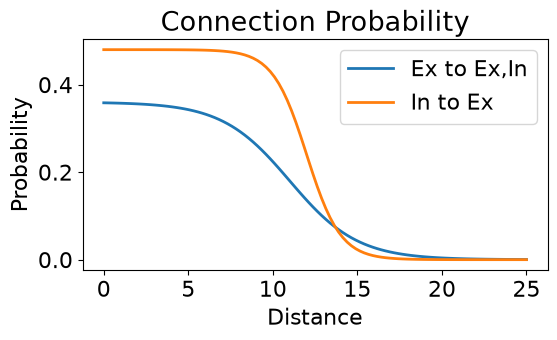

In [6]:
# Plot the connection probabilities
plt.figure(figsize=(6, 3))

conn_dist = np.linspace(0, 25, 100)
# Sigmoid probability equation
sig_ex = izhi_ex_proj['sigmoid']
sig_in = izhi_in_proj['sigmoid']
p_ex = sig_ex['maxprob']*(1 - 1/(1+np.exp(-sig_ex['slope']*(conn_dist-sig_ex['midpoint']))))
p_in = sig_in['maxprob']*(1 - 1/(1+np.exp(-sig_in['slope']*(conn_dist-sig_in['midpoint']))))

plt.plot(conn_dist, p_ex, linewidth=2, label='Ex to Ex,In')
plt.plot(conn_dist, p_in, linewidth=2, label='In to Ex')

plt.ylabel('Probability')
plt.xlabel('Distance')
plt.title('Connection Probability')
plt.legend()

## External Input Streams

In [7]:
# Input streams are specialized vertex models

# Parameterization for file-based input stream
input_param = {'n': n_izhi_input}
input_ports = {'input': 'input/input.yml'}

# Input substrate models
spike_input = stream_model('spike_input',
                           'spike_input',
                           params = input_param,
                           ports = input_ports)

syn_input = edge_model('syn_input',
                       'input_syn',
                       states = syn_input_state)

# Instantiate input as node in graph
io_spike_input = graph_stream('spike_input')

# Input connection information
spike_input_proj = {'uniform': {'prob': 1.0}}

conn_spike_input = graph_conn('spike_input',
                              'izhi_input',
                              'syn_input',
                              connect = spike_input_proj)

# Update the substrate model and graph dictionaries
substrate_models.extend([spike_input, syn_input])
graph_models.extend([io_spike_input, conn_spike_input])

In [1]:
# Create the input file for the spike input
spike_rate = 2.0 # Hz
spike_t_max = 10000.0 # ms
event_list = []
for n in range(n_izhi_input):
    evtlist = np.sort(np.round(np.random.rand(int(spike_rate*spike_t_max/1000))*spike_t_max))
    event_list.append(evtlist.tolist())

input_yaml = {'spike_list': event_list}

# Write input to file
fname = netwkdir + '/' + input_ports['input']
with open(fname,"w") as file:
    yaml.dump(input_yaml, file, sort_keys=False)

# Plot the event list just to see
plt.figure(figsize=(8,4))
plt.eventplot(event_list,colors='tab:green',lineoffsets=1,linelengths=1.0,linewidths=1.0)

plt.title('Tutorial Input Spike Raster')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron (index)')
plt.tight_layout()

NameError: name 'n_izhi_input' is not defined

## Writing out Network Configuration

In [9]:
# Generate the model file
fname = netwkdir + '/' + filebase + '.model'
with open(fname,"w") as file:
    # Each of these are their own YAML file
    substrate_yaml = generate_model_yaml(substrate_models)
    yaml.dump_all(substrate_yaml, file, sort_keys=False)

# Generate the graph file
fname = netwkdir + '/' + filebase + '.graph'
with open(fname,"w") as file:
    # Graph information is one file
    graph_yaml = generate_graph_yaml(graph_models)
    yaml.dump(graph_yaml, file, sort_keys=False)

# Simulating the Neural Network

## Simulation Configuration

In [10]:
# Main configuration
sim_conf = {'runmode': 'buildsim',
            'randseed': 1421}

# Partitions
part_conf = {'netwkdir': netwkdir,
             'recordir': recordir,
             'filebase': filebase,
             'netfiles': 4,
             'netparts': 16}

# Timing
time_conf = {'tstep': 1.0,    # ms
             'tmax': 60000.0} # ms

# Collect all these parameters into the same dictionary (with defaults)
conf_yaml = generate_conf_yaml(sim_conf, part_conf, time_conf)

# Generate the simulation configuration file
fname = netwkdir + '/' + filebase + '.yml'
with open(fname,"w") as file:
    yaml.dump(conf_yaml, file, sort_keys=False)

## Running the Simulation

In [11]:
# Path to STACS executables
stacsdir = '..'
charmrun = stacsdir + '/' + 'charmrun'
stacs = stacsdir + '/' + 'stacs'

# How many cores to run with
num_pe = 8
charm_pe = '+p' + str(num_pe)

# Simulation arguments
runconf = netwkdir + '/' + filebase + '.yml'
runmode = 'buildsim'

# Base command to run STACS
runcmd = charmrun + ' ' + charm_pe + ' ' + stacs + ' ' + runconf
print(runcmd)

# Run the simulation
!{runcmd + ' ' + runmode}

../charmrun +p8 ../stacs ./reservoir/network.yml
Charmrun> scalable start enabled. 
ssh: connect to host localhost port 22: Connection refused
Charmrun> Error 255 returned from remote shell (localhost:0)
Charmrun> Reconnection attempt 1 of 3
ssh: connect to host localhost port 22: Connection refused
Charmrun> Error 255 returned from remote shell (localhost:0)
Charmrun> Reconnection attempt 2 of 3
ssh: connect to host localhost port 22: Connection refused
Charmrun> Error 255 returned from remote shell (localhost:0)
Charmrun> Reconnection attempt 3 of 3
ssh: connect to host localhost port 22: Connection refused
Charmrun> Error 255 returned from remote shell (localhost:0)
Charmrun> Too many reconnection attempts; bailing out


## Reading Network Output

In [12]:
## Helper functions for visualization

# Get some simulation information (subset of sim_yaml)
def read_config(configfile):
    conf_dict = dict()
    with open(configfile,"r") as file:
        simconfig = yaml.safe_load(file)
    
    # Network and records directory
    conf_dict['netwkdir'] = simconfig['netwkdir']
    conf_dict['recordir'] = simconfig['recordir']
    print("Network directory: {}".format(conf_dict['netwkdir']))
    
    # Snapshot information
    conf_dict['filebase'] = simconfig['filebase']
    conf_dict['netfiles'] = int(simconfig['netfiles'])
    conf_dict['netparts'] = int(simconfig['netparts'])
    print("Network filebase: {}".format(conf_dict['filebase']))
    print("Number of files: {}".format(conf_dict['netfiles']))
    print("Number of parts: {}".format(conf_dict['netparts']))
    
    # Timing information
    conf_dict['tmax'] = float(simconfig['tmax'])
    conf_dict['tstep'] = float(simconfig['tstep'])
    conf_dict['trecord'] = float(simconfig['trecord'])
    print("Max simulation time: {}".format(conf_dict['tmax']))
    print("Simulation timestep: {}".format(conf_dict['tstep']))
    print("Recording interval: {}".format(conf_dict['trecord']))

    # Return dictionary
    return conf_dict

def read_graph(conf_dict):
    graphfile = conf_dict['netwkdir'] + '/' + conf_dict['filebase'] + '.graph'
    with open(graphfile,"r") as file:
        graphconfig = yaml.safe_load(file)
    
    # Vertex population sizes
    vertex_modname = []
    vertex_order = []
    # Section for streams
    for vertex in graphconfig['stream']:
        vertex_modname.append(vertex['modname'])
        vertex_order.append(1)
        print("Vertex model {} : {}".format(vertex['modname'], 1))
    # Section for vertices
    for vertex in graphconfig['vertex']:
        vertex_modname.append(vertex['modname'])
        vertex_order.append(vertex['order'])
        print("Vertex model {} : {}".format(vertex['modname'], vertex['order']))
    vertex_prefix = [0] + [sum(vertex_order[:i+1]) for i in range(len(vertex_order))]
    print("Prefix sum: {}".format(vertex_prefix))

    return vertex_modname, vertex_prefix

def calc_remap(conf_dict, vertex_modname, vertex_prefix):
    vertex_remap = np.zeros(vertex_prefix[-1]).astype(int)
    
    # global and per-population counters
    vertex_global_index = 0
    vertex_model_index = np.zeros(len(vertex_modname)).astype(int)
    
    # Loop through the state files
    for fileidx in range(conf_dict['netfiles']):
        fname = conf_dict['netwkdir'] + '/' + conf_dict['filebase'] + '.state.' + str(fileidx)
        with open(fname, 'r') as fstate:
            for line in fstate:
                # the vertex model name is the first word per line
                modname = line.split(None, 1)[0]
                vertex_remap[vertex_global_index] = vertex_prefix[vertex_modname.index(modname)] \
                                                  + vertex_model_index[vertex_modname.index(modname)]
                vertex_global_index += 1
                vertex_model_index[vertex_modname.index(modname)] += 1
    
    return vertex_remap

def calc_records(conf_dict):
    record_interval = int(conf_dict['trecord']/conf_dict['tstep'])
    record_max = int(conf_dict['tmax']/conf_dict['tstep'])
    record_points = list(range(record_interval, record_max, record_interval))+[record_max]
    print("Recording points: {}".format(record_points))
    return record_points

def read_spikes(conf_dict, record_points, vertex_prefix, vertex_remap):
    # Conversion from timestamp 'tick' to milliseconds
    TICKS_PER_MS = 1000000

    # Collect spikes into an event list
    event_list = [[] for _ in range(vertex_prefix[-1])]
    event_count = 0
    for record in record_points:
        for fileidx in range(conf_dict['netfiles']):
            fname = conf_dict['netwkdir'] + '/' + conf_dict['recordir'] + '/' + conf_dict['filebase'] + '.evtlog.' + str(record) + '.' + str(fileidx)
            with open(fname, 'r') as file:
                for line in file:
                    # the event format is [event type, timestamp, vertex index, optional payload]
                    event = line.split()
                    event_type = int(event[0])
                    timestamp = float(int(event[1], 16)) / TICKS_PER_MS
                    global_index = int(event[2])
                    # reindex the events
                    index = int(vertex_remap[global_index])
                    # spikes are event type "0"
                    if event_type == 0:
                        event_list[index].append(timestamp)
                        event_count += 1
    
    print("Total events: {}".format(event_count))

    return event_list

In [13]:
# Network simulation yaml
configfile = './reservoir/network.yml'
sim_config = read_config(configfile)
graph_modname, graph_prefix = read_graph(sim_config)

# Because the neuron models are distributed over multiple partitions,
# we need to find the reindexing mapping for cleaner plotting
graph_remap = calc_remap(sim_config, graph_modname, graph_prefix)

# Reading in data from event logs, which are stored 
# by recording interval in simulation iterations
record_points = calc_records(sim_config)
event_list = read_spikes(sim_config, record_points, graph_prefix, graph_remap)

Network directory: ./reservoir
Network filebase: network
Number of files: 4
Number of parts: 16
Max simulation time: 60000.0
Simulation timestep: 1.0
Recording interval: 10000.0
Vertex model spike_input : 1
Vertex model izhi_ex : 4000
Vertex model izhi_in : 1000
Vertex model izhi_input : 100
Prefix sum: [0, 1, 4001, 5001, 5101]


FileNotFoundError: [Errno 2] No such file or directory: './reservoir/network.state.0'

## Plotting Output

ValueError: colors and positions are unequal sized sequences

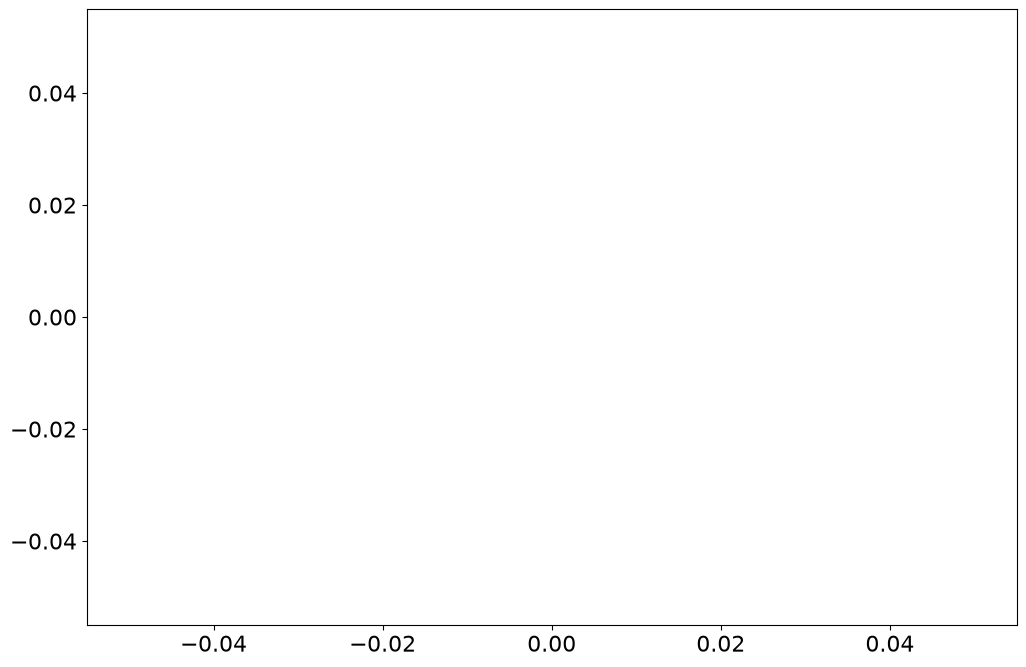

In [14]:
# Plot the event list information
plt.figure(figsize=(12,8))

# We can also color the rows according to population
color_dict = {'izhi_ex': 'tab:blue',
              'izhi_in': 'tab:orange',
              'izhi_input': 'tab:green',
              'spike_input': 'tab:red'}
event_color = []
for index, modname in enumerate(graph_modname):
    event_color.extend([color_dict[modname]] * (graph_prefix[index+1] - graph_prefix[index]))
# colored lines (for legend)
plt.plot(0,0,'-',color=color_dict['izhi_ex'],linewidth=2.0)
plt.plot(0,0,'-',color=color_dict['izhi_in'],linewidth=2.0)
plt.plot(0,0,'-',color=color_dict['izhi_input'],linewidth=2.0)

# The spike raster is plotted using eventplot
plt.eventplot(event_list,colors=event_color,lineoffsets=1,linelengths=1.0,linewidths=1.0)

plt.title('Tutorial PolyRect Spike Raster')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron (index)')
plt.tight_layout()
plt.legend(['Ex', 'In', 'Input'])

# Partitioning the Network

In [15]:
# Helper functions for partitioning

# Read the coordinate information
def read_coord(conf_dict, vertex_prefix):
    xyz = np.zeros((vertex_prefix[-1],3))
    vertex_counter = 0
    # Read coordinates from SNN-dCSR files
    for fileidx in range(conf_dict['netfiles']) :
        fname = conf_dict['netwkdir'] + '/' + conf_dict['filebase'] + '.coord.' + str(fileidx)
        with open(fname,'r') as file:
            for l, line in enumerate(file):
                xyz[vertex_counter] = np.array(line.split()[:3], dtype=float)
                vertex_counter += 1

    # Return coordinates
    return xyz

def calc_parts(conf_dict):
    # First find the partition distribution
    vertex_dist = np.zeros(conf_dict['netparts']+1).astype(int)
    fname = conf_dict['netwkdir'] + '/' + conf_dict['filebase'] + '.dist'
    with open(fname,'r') as file:
        for l, line in enumerate(file):
            vertex_dist[l] = line.split()[0]
            
    # Then populate the partition info
    part = []
    for part_index in range(len(vertex_dist) - 1):
        part.extend([part_index] * (vertex_dist[part_index+1] - vertex_dist[part_index]))

    # Return partition information
    return part

def plot_part(xyz, part):
    # Plot the coordinate data
    fig, ax = plt.subplots(figsize=(8,8))
    
    # We can also color the rows according to population
    part_color = []
    for p in range(len(part)):
        part_color.append('C{}'.format(part[p]))
    
    # Permute the order the points are scattered
    vertex_permute = np.random.permutation(np.arange(len(xyz)))
    graph_x_permute = [xyz[vertex_permute[p],0] for p in range(len(vertex_permute))]
    graph_y_permute = [xyz[vertex_permute[p],1] for p in range(len(vertex_permute))]
    part_color_permute = [part_color[vertex_permute[p]] for p in range(len(vertex_permute))]
    
    # Scatter plot of vertices and their partitions
    plt.scatter(graph_x_permute, graph_y_permute, c=part_color_permute)
    
    plt.title('Partition Distribution')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.gca().set_aspect('equal')
    plt.tight_layout()

    # Return axis for customization
    return ax

def write_part(conf_dict, part):
    # First find the file distribution
    vertex_metis = np.zeros(conf_dict['netfiles']+1).astype(int)
    fname = conf_dict['netwkdir'] + '/' + conf_dict['filebase'] + '.metis'
    with open(fname,'r') as file:
        for l, line in enumerate(file):
            vertex_metis[l] = line.split()[0]

    # Then write the partitions according to this
    for fileidx in range(conf_dict['netfiles']):
        fname = conf_dict['netwkdir'] + '/' + conf_dict['filebase'] + '.part.' + str(fileidx)
        with open(fname,'w') as file:
            for p in range(vertex_metis[fileidx+1] - vertex_metis[fileidx]):
                file.write('{}\n'.format(part[vertex_metis[fileidx]+p]))

# Compute updated vertex ordering after migration
def calc_reindex(vertex_part, vertex_remap, vertex_modname, vertex_prefix, modname):
    modidx = vertex_modname.index(modname)
    index_remap = np.zeros(vertex_prefix[modidx+1]-vertex_prefix[modidx]).astype(int)
    vertex_counter = 0
    # Get ordering based on new part
    for i, index in enumerate(vertex_remap):
        if (vertex_remap[index] >= vertex_prefix[modidx] and
            vertex_remap[index] < vertex_prefix[modidx+1]):
            index_remap[vertex_counter] = vertex_part[i]
            vertex_counter += 1
                    
    # Return sorted indices
    return np.argsort(index_remap)

## Randomized Partitioning

Text(0.5, 1.0, 'Randomized Partition Distribution')

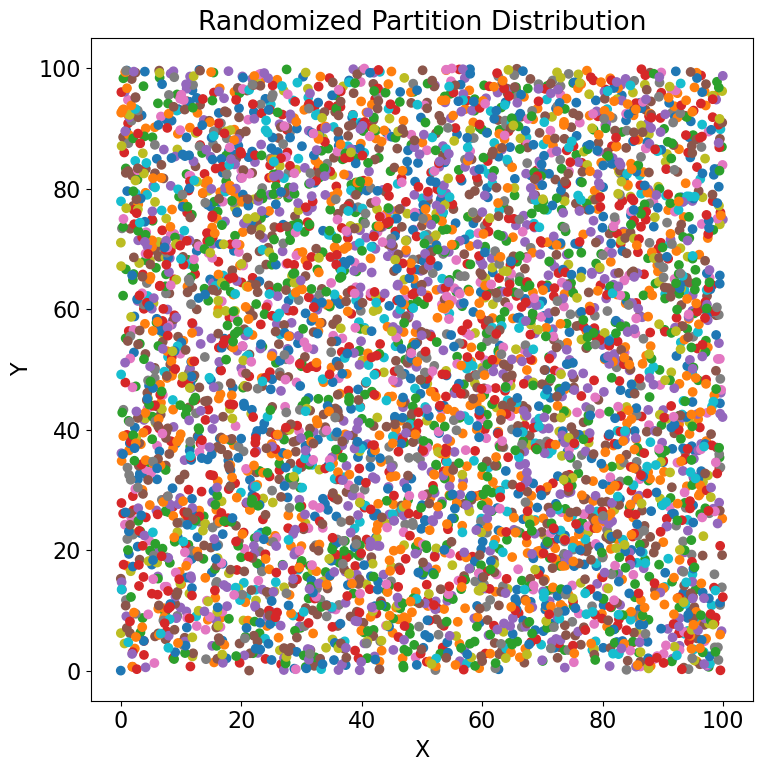

In [16]:
# We can repartition the network to something more efficient
graph_xyz = read_coord(sim_config, graph_prefix)
graph_part_orig = calc_parts(sim_config)

# Plot the original distribution (neurons were randomly distributed)
ax = plot_part(graph_xyz, graph_part_orig)
ax.set_title('Randomized Partition Distribution')

## Simple Spatial Partitioning

Text(0.5, 1.0, 'Spatially Partitioned Distribution')

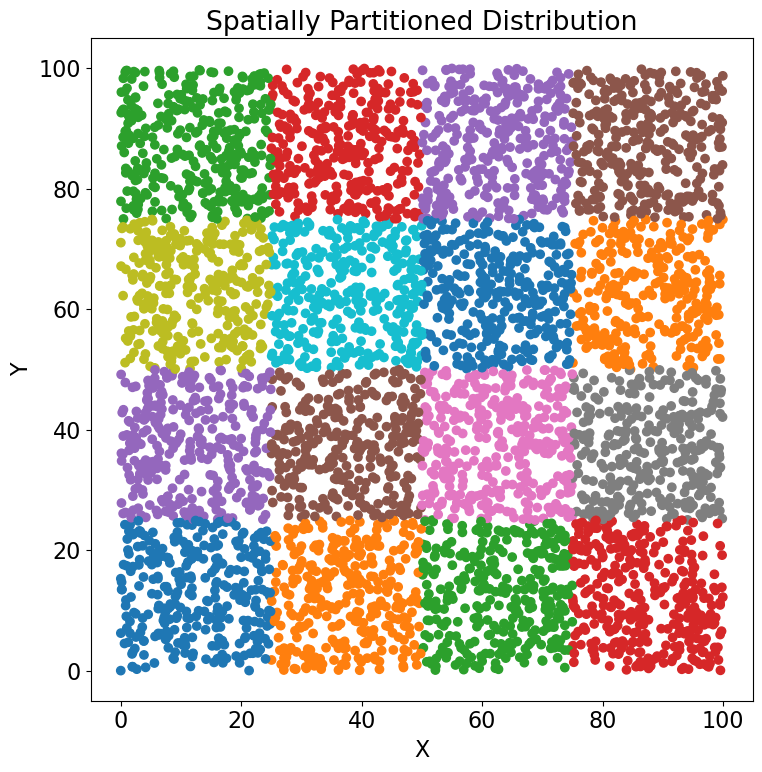

In [17]:
# Perform a spatial partitioning
# Assuming number of partitions was 16
grid_width = rect_w
grid_height = rect_h
n_split_x = 4
n_split_y = 4
split_width = rect_w / n_split_x
split_height = rect_h / n_split_y

# Assign partition to vertices
graph_part_new = np.zeros(len(graph_xyz)).astype(int)
for v, coord in enumerate(graph_xyz):
    vertex_gx = np.floor(coord[0] / split_width)
    vertex_gy = np.floor(coord[1] / split_height)
    # Assign in row-major order (y coord first)
    graph_part_new[v] = vertex_gy * n_split_x + vertex_gx

# Plot the new distribution
ax = plot_part(graph_xyz, graph_part_new)
ax.set_title('Spatially Partitioned Distribution')

## Repartitioning (migrating) Network

In [18]:
# In order to simulate this network with the new partitioning, we have
# to migrate the vertices from their original to their new parts
write_part(sim_config, graph_part_new)

# Migrate the vertices (and reindex the edges)
runmode = 'migrate'
!{runcmd + ' ' + runmode}


Running as 8 OS processes:  ../stacs ./reservoir/network.yml migrate 
charmrun> mpirun -np 8  ../stacs ./reservoir/network.yml migrate 
Charm++> Running on MPI version: 4.1
Charm++> level of thread support used: -1 (desired: 0)
Charm++> Running in non-SMP mode: 8 processes (PEs)
Converse/Charm++ Commit ID: v70000
Charm++ built without optimization.
Do not use for performance benchmarking (build with --with-production to do so).
Charm++ built with internal error checking enabled.
Do not use for performance benchmarking (build without --enable-error-checking to do so).
Isomalloc> Synchronized global address space.
CharmLB> Load balancer assumes all CPUs are same.
Charm++> Running on 1 hosts (1 sockets x 12 cores x 1 PUs = 12-way SMP)
Charm++> cpu topology info is gathered in 0.007 seconds.

Simulation Tool for Asynchronous Cortical Streams (stacs)
Reading config from ./reservoir/network.yml
Reading model information
  Model: 1   Name: spike_input   Type: 5   States: 0   Params: 1   Port

In [19]:
# Update the inputs to the migrated network
input_remap = calc_reindex(graph_part_new, graph_remap, graph_modname, graph_prefix, 'izhi_input')

# Read in original spike input
fname = netwkdir + '/' + input_ports['input']
with open(fname,'r') as file:
    input_yaml = yaml.safe_load(file)

# Reorder the inputs based on the updated order
input_yaml_new = dict()
input_yaml_new['spike_list'] = [input_yaml['spike_list'][i] for i in input_remap]

# Write this back out to file
with open(fname,"w") as file:
    yaml.dump(input_yaml_new, file, sort_keys=False)

## Simulating Repartitioned Network

In [20]:
# Simulate the newly partitioned network
runmode = 'simulate'
!{runcmd + ' ' + runmode}


Running as 8 OS processes:  ../stacs ./reservoir/network.yml simulate 
charmrun> mpirun -np 8  ../stacs ./reservoir/network.yml simulate 
Charm++> Running on MPI version: 4.1
Charm++> level of thread support used: -1 (desired: 0)
Charm++> Running in non-SMP mode: 8 processes (PEs)
Converse/Charm++ Commit ID: v70000
Charm++ built without optimization.
Do not use for performance benchmarking (build with --with-production to do so).
Charm++ built with internal error checking enabled.
Do not use for performance benchmarking (build without --enable-error-checking to do so).
Isomalloc> Synchronized global address space.
CharmLB> Load balancer assumes all CPUs are same.
Charm++> Running on 1 hosts (1 sockets x 12 cores x 1 PUs = 12-way SMP)
Charm++> cpu topology info is gathered in 0.010 seconds.

Simulation Tool for Asynchronous Cortical Streams (stacs)
Reading config from ./reservoir/network.yml
Reading model information
  Model: 1   Name: spike_input   Type: 5   States: 0   Params: 1   Po

## Plotting Output

Recording points: [10000, 20000, 30000, 40000, 50000, 60000]
Total events: 1073154


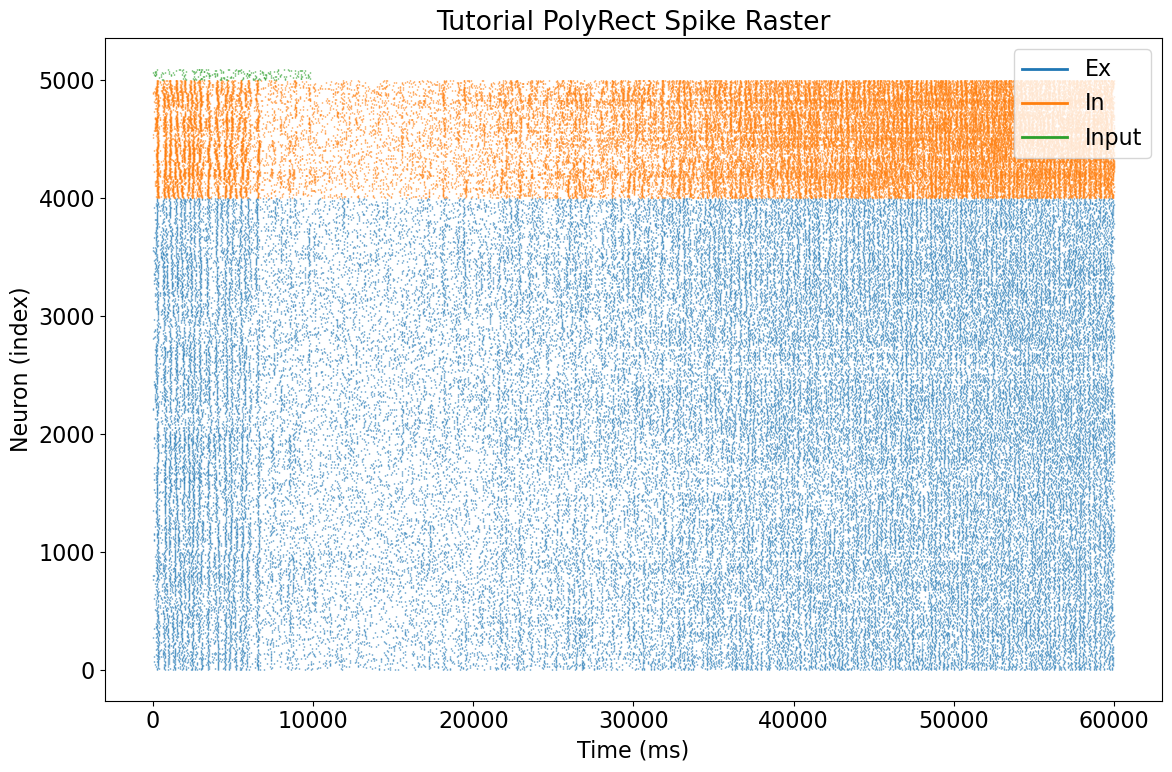

In [21]:
# Because the neuron models are distributed over multiple partitions,
# we need to find the reindexing mapping for cleaner plotting
graph_remap_new = calc_remap(sim_config, graph_modname, graph_prefix)

# Reading in data from event logs, which are stored 
# by recording interval in simulation iterations
record_points = calc_records(sim_config)
event_list = read_spikes(sim_config, record_points, graph_prefix, graph_remap_new)

# Plot the event list information
plt.figure(figsize=(12,8))

# We can also color the rows according to population
color_dict = {'izhi_ex': 'tab:blue',
              'izhi_in': 'tab:orange',
              'izhi_input': 'tab:green',
              'spike_input': 'tab:red'}
event_color = []
for index, modname in enumerate(graph_modname):
    event_color.extend([color_dict[modname]] * (graph_prefix[index+1] - graph_prefix[index]))
# colored lines (for legend)
plt.plot(0,0,'-',color=color_dict['izhi_ex'],linewidth=2.0)
plt.plot(0,0,'-',color=color_dict['izhi_in'],linewidth=2.0)
plt.plot(0,0,'-',color=color_dict['izhi_input'],linewidth=2.0)

# The spike raster is plotted using eventplot
plt.eventplot(event_list,colors=event_color,lineoffsets=1,linelengths=1.0,linewidths=1.0)

plt.title('Tutorial PolyRect Spike Raster')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron (index)')
plt.tight_layout()
plt.legend(['Ex', 'In', 'Input'])